# Coweeta AORC Meteorology for ELM CPL_BYPASS

This notebook downloads AORC hourly meteorological data for the Coweeta watershed
and converts it to the `atssubdaily` CPL_BYPASS format expected by ELM.

The CPL_BYPASS `atssubdaily` format consists of:
- One NetCDF file per variable, named `ATS-subdaily_<VAR>_z<ZZ>.nc`
- Each file has dimensions `(n, DTIME)` where `n` is the number of spatial zones
  and `DTIME` is hourly time in days since a reference date
- A `zone_mappings.txt` file mapping `(lon, lat)` grid points to zone indices

ELM variables produced:

| File variable | Description | Units |
| --- | --- | --- |
| `TBOT` | Air temperature at 2 m | K |
| `QBOT` | Specific humidity at 2 m | kg/kg |
| `WIND` | Wind speed at 10 m | m/s |
| `FLDS` | Incident longwave radiation | W/m² |
| `FSDS` | Incident shortwave radiation | W/m² |
| `PSRF` | Surface pressure | Pa |
| `PRECTmms` | Total precipitation | mm/s |

Output files are written to `elm_output_data/atm_forcing/` and are
referenced by `metdata_bypass` in `user_nl_elm`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import cftime
import netCDF4
import matplotlib.pyplot as plt

import watershed_workflow
import watershed_workflow.io
import watershed_workflow.sources
import watershed_workflow.utils
import watershed_workflow.properties.meteorology

watershed_workflow.io.setupLogging(1, None)
plt.rcParams['figure.figsize'] = (10, 4)

## Parameters

In [3]:
# -----------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------
def splitPathFull(path):
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:
            parts.insert(0, head); break
        elif tail == path:
            parts.insert(0, tail); break
        else:
            parts.insert(0, tail); path = head
    return parts

cwd = splitPathFull(os.getcwd())
if cwd[-1] == 'Coweeta':
    pass
elif cwd[-1] == 'examples':
    cwd.append('Coweeta')
else:
    cwd.extend(['examples', 'Coweeta'])

data_dir = os.path.join(*(cwd + ['input_data']))
def toInput(f): return os.path.join(data_dir, f)

output_dir = os.path.join(*(cwd + ['elm_output_data']))
os.makedirs(output_dir, exist_ok=True)
def toOutput(f): return os.path.join(output_dir, f)

# Output directory for CPL_BYPASS forcing files
atm_forcing_dir = toOutput('atm_forcing')
os.makedirs(atm_forcing_dir, exist_ok=True)

# Use local data cache so downloads are reused
watershed_workflow.utils.setDataDirectory(data_dir)

# -----------------------------------------------------------------------
# Watershed and time parameters
# -----------------------------------------------------------------------
coweeta_shapefile = toInput('coweeta_basin.shp')
crs = watershed_workflow.crs.default_crs

start_date = '2010-1-1'
end_date   = '2022-12-31'

print(f'Output dir        : {output_dir}')
print(f'ATM forcing dir   : {atm_forcing_dir}')
print(f'Date range        : {start_date} -- {end_date}')

Output dir        : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data
ATM forcing dir   : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/atm_forcing
Date range        : 2010-1-1 -- 2022-12-31


In [4]:
watershed_workflow.utils.config.rcParams['DEFAULT']['data_directory']



'/Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data'

## Load the Watershed

2026-08-04 15:20:56,921 - root - INFO: fixing column: geometry
2026-08-04 15:20:56,926 - root - INFO: Removing holes on 1 polygons
2026-08-04 15:20:56,926 - root - INFO:   -- removed interior
2026-08-04 15:20:56,926 - root - INFO:   -- union
2026-08-04 15:20:56,927 - root - INFO: Parsing 1 components for holes
2026-08-04 15:20:56,927 - root - INFO:   -- complete


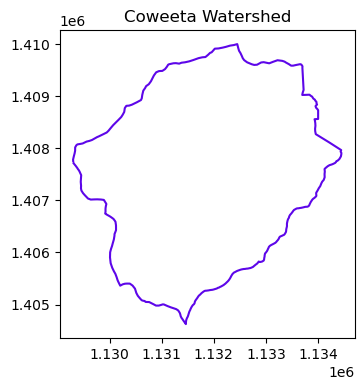

In [5]:
coweeta_source = watershed_workflow.sources.ManagerShapefile(coweeta_shapefile, id_name='BASIN_CODE')
coweeta = coweeta_source.getShapes(out_crs=crs)
watershed = watershed_workflow.Watershed(coweeta)
watershed_workflow.hydro.simplify(watershed, 60)
watershed.plot()
plt.title('Coweeta Watershed')
plt.show()

## Download AORC Data

AORC provides hourly gridded meteorology at ~800 m resolution over CONUS from 1979–present.
Data are fetched from the ORNL DAAC Zarr store and cached locally.

In [6]:
source = watershed_workflow.sources.ManagerAORC()
met_data = source.getDataset(coweeta, start=start_date, end=end_date)
met_data

2026-08-04 15:20:57,023 - root - INFO: Incoming shape area = 0.001605859074385773
2026-08-04 15:20:57,023 - root - INFO: ... buffering incoming shape by 3x native resolution = 0.02499999
2026-08-04 15:20:57,025 - root - INFO: ... buffered shape area = 0.007628636630660812
2026-08-04 15:20:57,026 - root - INFO: ManagerAORC: cache hit at /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/meteorology/aorc/ornl_daac_zarr/ornl_daac_zarr_2010-2022_native_-83.5083_35.0000_-83.3916_35.1000


<xarray.Dataset> Size: 1GB
Dimensions:              (latitude: 12, longitude: 14, time: 113929)
Coordinates:
  * latitude             (latitude) float64 96B 35.01 35.02 35.02 ... 35.09 35.1
  * longitude            (longitude) float64 112B -83.5 -83.49 ... -83.4 -83.39
  * time                 (time) object 911kB 2010-01-01 00:00:00 ... 2022-12-...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time, latitude, longitude) float64 153MB ...
    DLWRF_surface        (time, latitude, longitude) float64 153MB ...
    DSWRF_surface        (time, latitude, longitude) float64 153MB ...
    PRES_surface         (time, latitude, longitude) float64 153MB ...
    SPFH_2maboveground   (time, latitude, longitude) float64 153MB ...
    TMP_2maboveground    (time, latitude, longitude) float64 153MB ...
    UGRD_10maboveground  (time, latitude, longitude) float64 153MB ...
    VGRD_10maboveground  (time, latitude, longitude) float64 153MB ...
Attributes:
    product:  AORC
    source:   ORNL DAAC Zarr

## Convert AORC to ELM CPL_BYPASS Format

The `atssubdaily` CPL_BYPASS format stores each ELM forcing variable in a
separate NetCDF file.  Each file has:
- Dimension `n`: spatial zones (one per distinct grid cell / lat-lon point)
- Dimension `DTIME`: hourly timesteps in fractional days since a reference date
- Variables `LONGXY(n)`, `LATIXY(n)`: zone center coordinates
- Variable `<VAR>(n, DTIME)`: the forcing data
- Scalar variables `start_year`, `end_year`

The `zone_mappings.txt` file lists every ELM column's (lon, lat) and its zone
assignment (row, col indices into the zone grid).  When the grid has one zone
per AORC cell, every ELM column maps to its nearest AORC neighbor.

In [7]:
met_elm = watershed_workflow.properties.meteorology.convertAORCToELM(met_data)
met_elm

2026-08-04 15:20:57,308 - root - INFO: Converting AORC to ELM CPL_BYPASS met input


<xarray.Dataset> Size: 1GB
Dimensions:      (latitude: 12, longitude: 14, time: 113929)
Coordinates:
  * latitude     (latitude) float64 96B 35.01 35.02 35.02 ... 35.08 35.09 35.1
  * longitude    (longitude) float64 112B -83.5 -83.49 -83.49 ... -83.4 -83.39
  * time         (time) object 911kB 2010-01-01 00:00:00 ... 2022-12-31 00:00:00
    spatial_ref  int64 8B 0
Data variables:
    TBOT         (time, latitude, longitude) float64 153MB ...
    QBOT         (time, latitude, longitude) float64 153MB ...
    WIND         (time, latitude, longitude) float64 153MB 3.302 3.206 ... 1.105
    FLDS         (time, latitude, longitude) float64 153MB ...
    FSDS         (time, latitude, longitude) float64 153MB ...
    PSRF         (time, latitude, longitude) float64 153MB ...
    PRECTmms     (time, latitude, longitude) float64 153MB 0.0 0.0 ... 0.0 0.0
Attributes:
    product:  AORC
    source:   ORNL DAAC Zarr

## Mean Precipitation Rate (for ATS Stage 1a Steady-State Spinup)

Stage 1a of the multi-stage spinup workflow (`examples/coweeta/build_example.sh`) is a
pure ATS run forced with a spatially uniform, constant-in-time precipitation rate. That
XML is written independently by `coweeta_elm_ats.ipynb`, which does not download met
data itself. To avoid downloading AORC twice, we compute the domain- and time-mean
precipitation rate here (from the same `met_elm` data already fetched above) and write
it to a small text file. `build_example.sh` reads this file and substitutes the value
into stage 1a's XML at build time.

In [8]:
# PRECTmms is total precip (rain + snow) in mm/s (ELM CPL_BYPASS units).
# Convert to a domain- and time-mean rate in m/s for ATS's steady-state forcing.
mean_precip_mps = float(np.nanmean(met_elm['PRECTmms'])) / 1000.0

mean_precip_path = toOutput('coweeta_mean_precip_rain_mps.txt')
with open(mean_precip_path, 'w') as f:
    f.write(f'{mean_precip_mps:.10e}\n')

print(f'Mean precipitation rate: {mean_precip_mps:.6e} m/s '
      f'({mean_precip_mps * 1000 * 86400 * 365:.1f} mm/yr)')
print('Wrote:', mean_precip_path)

Mean precipitation rate: 6.147529e-08 m/s (1938.7 mm/yr)
Wrote: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_mean_precip_rain_mps.txt


## Quick Sanity Check: Plot One Pixel

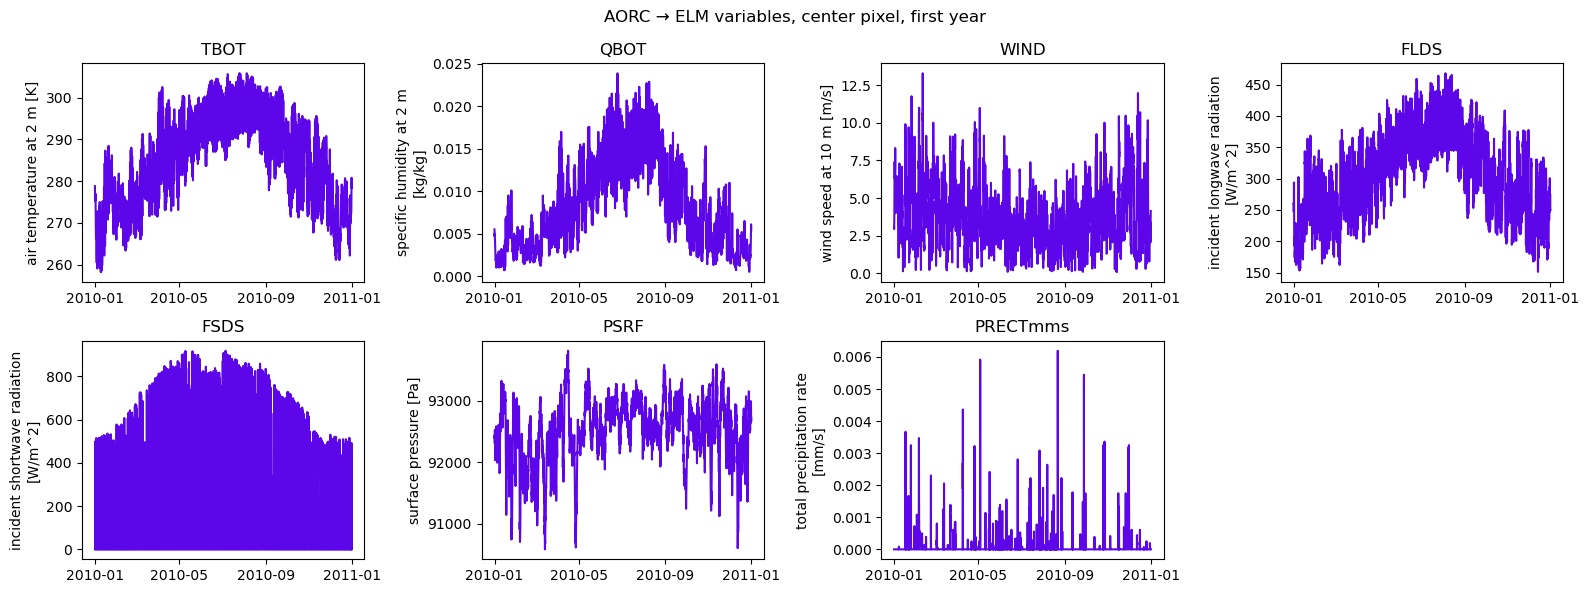

In [9]:
# Pick the center pixel
ilat = met_elm.sizes['latitude'] // 2
ilon = met_elm.sizes['longitude'] // 2
pix = met_elm.isel(latitude=ilat, longitude=ilon, time=slice(0, 24*365))

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, var in zip(axes.ravel(), ['TBOT', 'QBOT', 'WIND', 'FLDS', 'FSDS', 'PSRF', 'PRECTmms']):
    pix[var].plot(ax=ax)
    ax.set_title(var)
    ax.set_xlabel('')
axes.ravel()[-1].set_visible(False)
plt.suptitle('AORC → ELM variables, center pixel, first year')
plt.tight_layout()
plt.show()

## Build Zone Grid

Each AORC lat-lon grid cell becomes one row in the `n` dimension of a
single `_z01.nc` file per variable (row-major, lat outer / lon inner).
`zone_mappings.txt` (written below) maps every ELM column to its nearest
AORC cell's flat row index.

In [10]:
lats = met_elm['latitude'].values   # 1-D, ascending
lons = met_elm['longitude'].values  # 1-D, ascending

nlat = len(lats)
nlon = len(lons)
nzones = nlat * nlon

# Flat arrays of zone center coordinates, row-major (lat outer, lon inner)
zone_lats = np.repeat(lats, nlon)   # shape (nzones,)
zone_lons = np.tile(lons, nlat)     # shape (nzones,)

print(f'Grid: {nlat} lats x {nlon} lons = {nzones} zones')
print(f'Lat range : {lats.min():.4f} – {lats.max():.4f}')
print(f'Lon range : {lons.min():.4f} – {lons.max():.4f}')

Grid: 12 lats x 14 lons = 168 zones
Lat range : 35.0077 – 35.0994
Lon range : -83.5019 – -83.3935


## Write zone_mappings.txt

Format: `lon  lat  zone  grid` (1-based). ELM's CPL_BYPASS reader
(`lnd_import_export.F90`) reads these exact four columns: column 3 is the
`_z<NN>.nc` file-suffix to open, column 4 is the flat 1-based row index
into that file's `n` dimension. Since every AORC cell is stored as a row
in a single `z01.nc` file (not one file per zone), column 3 is a constant
`1` for every row, and column 4 is `ilat*nlon + ilon + 1` -- the same
row-major flat index used by `data_flat = arr.reshape(ntime, nzones).T`
below, so each row's grid index lines up with its position in `n`.

In [11]:
zone_mappings_path = os.path.join(atm_forcing_dir, 'zone_mappings.txt')

with open(zone_mappings_path, 'w') as f:
    for ilat in range(nlat):
        for ilon in range(nlon):
            f.write(f'{lons[ilon]:12.5f}  {lats[ilat]:12.6f}  {1:5d}  {ilat*nlon + ilon + 1:5d} \n')

print(f'Wrote {nzones} zone entries to: {zone_mappings_path}')

Wrote 168 zone entries to: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/atm_forcing/zone_mappings.txt


## Compute DTIME Array

`DTIME` is fractional days since `{start_year}-01-01 00:00:00`.  For hourly data
the step is 1/24 days.

In [12]:
# met_elm['time'] holds cftime.DatetimeGregorian objects (AORC's native
# calendar) -- these are not convertible to pandas/numpy datetime64, so work
# with them directly rather than routing through pd.DatetimeIndex (matching
# the same approach used below for the typical-year DTIME computation).
times_cf = met_elm['time'].values
start_year = int(times_cf[0].year)
end_year   = int(times_cf[-1].year)
ref_date_cf = cftime.datetime(start_year, 1, 1, calendar=times_cf[0].calendar)

dtime = np.array([(t - ref_date_cf).total_seconds() / 86400.0 for t in times_cf],
                 dtype=np.float64)
ntime = len(dtime)

print(f'ntime   = {ntime}  ({ntime/24:.0f} days, {ntime/24/365:.2f} years)')
print(f'DTIME[0]= {dtime[0]:.6f}   DTIME[-1]= {dtime[-1]:.6f}')
print(f'dt (h)  = {(dtime[1]-dtime[0])*24:.4f}')
print(f'Years   : {start_year} – {end_year}')

ntime   = 113929  (4747 days, 13.01 years)
DTIME[0]= 0.000000   DTIME[-1]= 4747.000000
dt (h)  = 1.0000
Years   : 2010 – 2022


## Write Transient CPL_BYPASS NetCDF Files

Writes the **transient** forcing set -- the full 2010-2022 hourly AORC record
converted to ELM variables above, one file per ELM variable, to
`elm_output_data/atm_forcing/`. This is the forcing **stage 3** (the final
transient run) uses; stages 1b and 2 instead use the cyclic "typical year"
set written to `atm_forcing_spinup/` by the next section below.

Each file is named `ATS-subdaily_<VAR>_z01.nc`. The `z01` suffix is a fixed
file-group index in ELM's CPL_BYPASS reader (`lnd_import_export.F90`), not a
per-cell zone -- all `nzones` AORC grid cells are stored as rows of the `n`
dimension inside that single file. ELM selects the row for each column via
`zone_mappings.txt`'s 4th column (see the Write zone_mappings.txt section
above). Data are packed as `int16` with scale/offset to match the format of
the reference CPL_BYPASS files.

In [13]:
def packInt16(data_2d):
    """Pack float64 array (nzones, ntime) to int16 with scale/offset."""
    vmin = float(np.nanmin(data_2d))
    vmax = float(np.nanmax(data_2d))
    vrange = max(vmax - vmin, 1e-30)
    add_offset   = (vmax + vmin) / 2.0
    scale_factor = vrange / (2**15 - 1) * 0.5
    packed = np.round((data_2d - add_offset) / scale_factor).astype(np.int16)
    return packed, scale_factor, add_offset


def writeCplBypassFile(filepath, varname, data_flat, zone_lons, zone_lats,
                          dtime, start_year, end_year, ref_date_str):
    """Write a single CPL_BYPASS NetCDF file.

    Parameters
    ----------
    filepath : str
    varname  : str   ELM variable name (e.g. 'TBOT')
    data_flat : ndarray shape (nzones, ntime)  float64
    zone_lons, zone_lats : 1-D coordinate arrays
    dtime     : 1-D float64 array of fractional days
    start_year, end_year : int
    ref_date_str : str  e.g. '2010-01-01 00:00:00'
    """
    packed, scale_factor, add_offset = packInt16(data_flat)

    with netCDF4.Dataset(filepath, 'w', format='NETCDF4_CLASSIC') as ds:
        ds.createDimension('DTIME', data_flat.shape[1])
        ds.createDimension('n', data_flat.shape[0])
        ds.createDimension('scalar', 1)

        v = ds.createVariable('DTIME', 'f8', ('DTIME',))
        v.units = f'days since {ref_date_str}'
        v.long_name = 'Day of Year'
        v[:] = dtime

        ds.createVariable('LONGXY', 'f8', ('n',))[:] = zone_lons
        ds.createVariable('LATIXY', 'f8', ('n',))[:] = zone_lats

        # packInt16() packs into the full symmetric int16 range [-32767, 32767]
        # (never -32768), so -32768 is safe to reserve as the fill value --
        # must be set at creation time via fill_value=, before any write.
        # Without this, netCDF4's reader falls back to its own default int16
        # fill value (also -32767) and silently masks out every real data
        # point that happens to pack to that value (e.g. every timestep at
        # the variable's true minimum), corrupting any aggregate computed
        # from the auto-scaled/masked read.
        vd = ds.createVariable(varname, 'i2', ('n', 'DTIME'), fill_value=-32768)
        # packed is already quantized to int16 by packInt16() above -- write it
        # verbatim. netCDF4 auto-applies (x-add_offset)/scale_factor on write
        # whenever those attributes are set on the variable, which would
        # re-pack (i.e. double-pack) already-packed integers and corrupt the
        # data. Disable auto-scaling for the write, then set the attributes
        # afterward so readers still auto-unpack correctly.
        vd.set_auto_maskandscale(False)
        vd[:] = packed
        vd.scale_factor = scale_factor
        vd.add_offset   = add_offset

        ds.createVariable('start_year', 'i4', ('scalar',))[:] = start_year
        ds.createVariable('end_year',   'i4', ('scalar',))[:] = end_year

    print(f'  Wrote: {os.path.basename(filepath)}')


ref_date_str = f'{start_year}-01-01 00:00:00'
elm_vars = ['TBOT', 'QBOT', 'WIND', 'FLDS', 'FSDS', 'PSRF', 'PRECTmms']

print(f'Writing {len(elm_vars)} CPL_BYPASS files to: {atm_forcing_dir}')
print(f'  Grid: {nlat} x {nlon} = {nzones} zones,  {ntime} timesteps')
print()

for varname in elm_vars:
    arr = met_elm[varname].values  # (ntime, nlat, nlon)
    data_flat = arr.reshape(ntime, nzones).T  # (nzones, ntime), row-major lat outer
    fpath = os.path.join(atm_forcing_dir, f'ATS-subdaily_{varname}_z01.nc')
    writeCplBypassFile(fpath, varname, data_flat, zone_lons, zone_lats,
                          dtime, start_year, end_year, ref_date_str)

print()
print('Done.')

Writing 7 CPL_BYPASS files to: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/atm_forcing
  Grid: 12 x 14 = 168 zones,  113929 timesteps

  Wrote: ATS-subdaily_TBOT_z01.nc
  Wrote: ATS-subdaily_QBOT_z01.nc
  Wrote: ATS-subdaily_WIND_z01.nc
  Wrote: ATS-subdaily_FLDS_z01.nc
  Wrote: ATS-subdaily_FSDS_z01.nc
  Wrote: ATS-subdaily_PSRF_z01.nc
  Wrote: ATS-subdaily_PRECTmms_z01.nc

Done.


## Compute and Write Cyclic CPL_BYPASS NetCDF Files (for ELM+ATS Spinup Stages 1b and 2)

Stages 1b and 2 of the multi-stage spinup workflow require cyclic met forcing
that represents a climatologically typical year at **hourly** resolution,
repeated (`const_climate_hist = .true.`) rather than run through the full
2010-2022 record. This section computes that typical year, then writes it
out in the same CPL_BYPASS format as the transient section above -- one
`ATS-subdaily_<VAR>_z01.nc` file per ELM variable, this time to
`elm_output_data/atm_forcing_spinup/` -- reusing the same `writeCplBypassFile()`
helper and the same `zone_lats`/`zone_lons` grid (only `dtime`, `start_year`,
and `end_year` differ, since the typical year is a synthetic short calendar,
not real dates).

`computeTypicalYear` works on ELM CPL_BYPASS-format data here (`met_elm`,
from the section above):
- All non-precipitation variables are averaged across years in each
  `(day-of-year, hour-of-day)` bin, preserving the full diurnal cycle.
- Precipitation uses the raw hourly values from the median-total-precipitation
  year, avoiding the artificial drizzle that hourly averaging would produce.

The result is written to `atm_forcing_spinup/` alongside a copy of the same
`zone_mappings.txt` written above (the spatial grid doesn't change between
the transient and typical-year sets, only the time axis).

In [14]:
# Number of times to repeat the typical year in the output file.
# ELM cycles this via const_climate_hist=.true., so nyears_typical=1 is
# sufficient -- ELM loops the stored period every model year regardless of
# how many repeats are physically written, so storing more would only waste
# disk/IO with no effect on model behavior.
nyears_typical = 1

# Compute the typical year directly from ELM-format data.
# - precip_vars=['PRECTmms']: treat total precip as the median-year variable
# - temp_var=None: no rain/snow re-splitting (ELM handles that internally)
# - combine_precip=False: only one precip var, so no combining needed
met_typical_elm = watershed_workflow.properties.meteorology.computeTypicalYear(
    met_elm,
    repeat_nyears=nyears_typical,
    precip_vars=['PRECTmms'],
    temp_var=None,
    combine_precip=False,
)
print(f'Typical year dataset: {met_typical_elm.sizes}')
#print(f'  data shape: {met_typical_elm['PRECTmms'].shape}')
print(met_typical_elm)
print(f'Time range: {met_typical_elm["time"].values[0]} – {met_typical_elm["time"].values[-1]}')

# Build DTIME array from the cftime noleap time coordinate.
ats_times = met_typical_elm['time'].values
ref_cftime_day0 = cftime.DatetimeNoLeap(ats_times[0].year, 1, 1)
dtime_typical = np.array(
    [(t - ref_cftime_day0).days + (t.hour / 24.0) for t in ats_times],
    dtype=np.float64,
)
start_year_typical = ats_times[0].year
end_year_typical   = ats_times[-1].year

# Write CPL_BYPASS files to atm_forcing_spinup/
atm_forcing_spinup_dir = toOutput('atm_forcing_spinup')
os.makedirs(atm_forcing_spinup_dir, exist_ok=True)

ntime_typical = len(dtime_typical)
ref_date_str_typical = f'{start_year_typical}-01-01 00:00:00'

print(f'\nWriting {len(elm_vars)} CPL_BYPASS spinup files to: {atm_forcing_spinup_dir}')
print(f'  {ntime_typical} timesteps ({ntime_typical / 24 / 365:.1f} typical years), {nzones} zones')
print()

for varname in elm_vars:
    da = met_typical_elm[varname]
    arr = da.values  # (ntime_typical, nlat, nlon)
    data_flat = arr.reshape(ntime_typical, nzones).T  # (nzones, ntime)
    fpath = os.path.join(atm_forcing_spinup_dir, f'ATS-subdaily_{varname}_z01.nc')
    if varname == 'PRECTmms':
        print(f'[DEBUG {varname}] da.dims={da.dims} da.shape={da.shape}')
        print(f'[DEBUG {varname}] da mean={float(da.mean()):.6e}  min={float(da.min()):.6e}  max={float(da.max()):.6e}  nunique={len(np.unique(da.values))}')
        print(f'[DEBUG {varname}] arr mean={np.nanmean(arr):.6e}  min={np.nanmin(arr):.6e}  max={np.nanmax(arr):.6e}  nunique={len(np.unique(arr))}')
        print(f'[DEBUG {varname}] data_flat mean={np.nanmean(data_flat):.6e}  min={np.nanmin(data_flat):.6e}  max={np.nanmax(data_flat):.6e}  nunique={len(np.unique(data_flat))}')
    writeCplBypassFile(fpath, varname, data_flat, zone_lons, zone_lats,
                          dtime_typical, start_year_typical, end_year_typical,
                          ref_date_str_typical)
    if varname == 'PRECTmms':
        check_ds = netCDF4.Dataset(fpath)
        check_ds.set_auto_maskandscale(False)
        raw_packed = check_ds.variables['PRECTmms'][:]
        print(f'[DEBUG {varname}] written file raw packed int16: min={raw_packed.min()} max={raw_packed.max()} nunique={len(np.unique(raw_packed))}')
        check_ds.set_auto_maskandscale(True)
        decoded = check_ds.variables['PRECTmms'][:]
        print(f'[DEBUG {varname}] written file decoded mean={np.nanmean(decoded):.6e}  -> mm/yr={np.nanmean(decoded)*86400*365:.1f}')
        check_ds.close()

# zone_mappings.txt is identical to the transient one (same spatial grid)
shutil.copy(zone_mappings_path, os.path.join(atm_forcing_spinup_dir, 'zone_mappings.txt'))
print(f'\nCopied zone_mappings.txt → {atm_forcing_spinup_dir}')
print('Done writing spinup forcing.')

2026-08-04 15:20:58,662 - root - INFO: Computing a typical year.


Typical year dataset: Frozen({'time': 8760, 'latitude': 12, 'longitude': 14})
<xarray.Dataset> Size: 82MB
Dimensions:      (time: 8760, latitude: 12, longitude: 14)
Coordinates:
  * time         (time) object 70kB 2009-01-01 00:00:00 ... 2009-12-31 23:00:00
  * latitude     (latitude) float64 96B 35.01 35.02 35.02 ... 35.08 35.09 35.1
  * longitude    (longitude) float64 112B -83.5 -83.49 -83.49 ... -83.4 -83.39
    spatial_ref  int64 8B 0
Data variables:
    TBOT         (time, latitude, longitude) float64 12MB 275.4 275.7 ... 279.7
    QBOT         (time, latitude, longitude) float64 12MB 0.00435 ... 0.004875
    WIND         (time, latitude, longitude) float64 12MB 4.031 4.381 ... 2.224
    FLDS         (time, latitude, longitude) float64 12MB 262.2 263.0 ... 264.7
    FSDS         (time, latitude, longitude) float64 12MB 0.0 0.0 ... 0.0 0.0
    PSRF         (time, latitude, longitude) float64 12MB 8.717e+04 ... 9.41e+04
    PRECTmms     (time, latitude, longitude) float64 12MB 0.0 

## Verify Output Files

In [15]:
print('Files written to', atm_forcing_dir)
for f in sorted(os.listdir(atm_forcing_dir)):
    fpath = os.path.join(atm_forcing_dir, f)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {f:<45}  {size_mb:6.1f} MB')

Files written to /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/atm_forcing
  ATS-subdaily_FLDS_z01.nc                         39.2 MB
  ATS-subdaily_FSDS_z01.nc                         39.2 MB
  ATS-subdaily_PRECTmms_z01.nc                     39.2 MB
  ATS-subdaily_PSRF_z01.nc                         39.2 MB
  ATS-subdaily_QBOT_z01.nc                         39.2 MB
  ATS-subdaily_TBOT_z01.nc                         39.2 MB
  ATS-subdaily_WIND_z01.nc                         39.2 MB
  zone_mappings.txt                                 0.0 MB


In [16]:
# Round-trip check: read back TBOT and compare to source
ds_check = netCDF4.Dataset(os.path.join(atm_forcing_dir, 'ATS-subdaily_TBOT_z01.nc'))
print('Dimensions :', {k: len(v) for k, v in ds_check.dimensions.items()})
print('start_year :', int(ds_check['start_year'][:]))
print('end_year   :', int(ds_check['end_year'][:]))
tbot_back = ds_check['TBOT'][:]
print(f'TBOT shape : {tbot_back.shape}  (nzones x ntime)')
expected = float(met_elm['TBOT'].values[0, 0, 0])
print(f'TBOT[0,0]  = {tbot_back[0,0]:.4f} K  (expected ~{expected:.4f} K)')
ds_check.close()

Dimensions : {'DTIME': 113929, 'n': 168, 'scalar': 1}
start_year : 2010
end_year   : 2022
TBOT shape : (168, 113929)  (nzones x ntime)
TBOT[0,0]  = 276.6996 K  (expected ~276.7000 K)


## Meteorology Output Locations

The CPL_BYPASS forcing this notebook writes (`atm_forcing/`, `atm_forcing_spinup/`)
must eventually sit somewhere `metdata_bypass` in `user_nl_elm` can point to.
This notebook does not write `user_nl_elm` itself -- `build_example.sh` is the
sole author of that file for every ELM-running stage (see
`coweeta_elm_ats.ipynb`'s Stage 3 section for why), and `stage_inputdata.sh`
picks up these forcing directories automatically once you copy them into
`examples/coweeta/` (see the Summary cell below).

## Summary

**Transient forcing** written to `elm_output_data/atm_forcing/`:

| File | Contents |
| --- | --- |
| `ATS-subdaily_TBOT_z01.nc` | Air temperature [K] |
| `ATS-subdaily_QBOT_z01.nc` | Specific humidity [kg/kg] |
| `ATS-subdaily_WIND_z01.nc` | Wind speed [m/s] |
| `ATS-subdaily_FLDS_z01.nc` | Longwave radiation [W/m²] |
| `ATS-subdaily_FSDS_z01.nc` | Shortwave radiation [W/m²] |
| `ATS-subdaily_PSRF_z01.nc` | Surface pressure [Pa] |
| `ATS-subdaily_PRECTmms_z01.nc` | Precipitation [mm/s] |
| `zone_mappings.txt` | (lon, lat) → zone index map |

**Hourly typical-year spinup forcing** written to `elm_output_data/atm_forcing_spinup/`
(same files, `nyears_typical` repeats of the representative annual cycle):

| File | Contents |
| --- | --- |
| `ATS-subdaily_*.nc` | Same variables, typical-year values |
| `zone_mappings.txt` | Identical to transient (same grid) |

Also written to `elm_output_data/`:

| File | Contents |
| --- | --- |
| `coweeta_mean_precip_rain_mps.txt` | domain/time-mean precip rate [m/s] for stage 1a |

**Next steps:**

No copy step needed -- `build_example.sh`'s `stage_inputdata.sh` helper reads
directly from `watershed_workflow/examples/Coweeta/elm_output_data/` (this
notebook's output directory, shared with `coweeta_elm_ats.ipynb`) and stages
these forcing directories and the mean-precip file into the campaign's
shared `inputdata/` automatically. See `examples/coweeta/README.md` for the
full campaign build/run sequence.

Build and run cases via `examples/coweeta/build_example.sh`.